## Paquid dataset application using the `jmstate` package

In [ ]:
%pip install -q jmstate==0.14.1 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import torch

In [37]:
torch.manual_seed(42)

paquid = pd.read_csv("../data/paquid.csv")

# Convert all numeric columns to float32
numeric_cols = paquid.select_dtypes(include="number").columns
paquid[numeric_cols] = paquid[numeric_cols].astype("float32")

In [38]:
groups = paquid.groupby("ID")
ids = range(1, 501)
pad = torch.nn.utils.rnn.pad_sequence

trajectories, c, t, y, X = [], [], [], [], []

for i in ids:
    g = groups.get_group(i)

    s = g.groupby("HIER")["age"].min().reindex(range(4)).dropna()
    s = s[s >= s.cummax()]
    trajectories.append([((float(a) - 65) / 10, int(k)) for k, a in s.items()])

    c.append((g["age"].max() - 65) / 10)
    t.append((torch.tensor(g["age"].values) - 65) / 10)
    y.append(torch.tensor(g["MMSE"].values / 30))
    X.append(torch.tensor(g[["CEP", "male"]].iloc[0].values))

c = torch.tensor(c)[:, None]
t = pad(t, batch_first=True, padding_value=torch.nan)
y = pad(y, batch_first=True, padding_value=torch.nan)[..., None]
x = torch.stack(X)

In [39]:
from jmstate.utils import build_buckets

buckets = build_buckets(trajectories)
print({k: v.idxs.numel() for k, v in buckets.items()})

{(0, 1): 85, (0, 2): 44, (0, 3): 11, (1, 2): 135, (1, 3): 15, (2, 3): 86}


In [ ]:
from jmstate.types import ModelDesign


def sigmoid(t: torch.Tensor, indiv_params: torch.Tensor):
    slope, offset = indiv_params.chunk(2, dim=-1)
    return torch.sigmoid((offset - t) / slope).unsqueeze(-1)


def f(pop: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    indiv_params = pop + b
    indiv_params[..., 0] = indiv_params[..., 0].exp()
    return indiv_params


# Define model design and link functions
link_fns = dict.fromkeys(buckets, sigmoid)
design = ModelDesign(f, sigmoid, link_fns)

In [41]:
from jmstate.types import ModelData
from sklearn.model_selection import train_test_split

(
    x_train,
    x_test,
    t_train,
    t_test,
    y_train,
    y_test,
    trajectories_train,
    trajectories_test,
    c_train,
    c_test,
) = train_test_split(x, t, y, trajectories, c, test_size=0.2, random_state=42)

data_train = ModelData(x_train, t_train, y_train, trajectories_train, c_train)
data_test = ModelData(x_test, t_test, y_test, trajectories_test, c_test)

In [42]:
from jmstate import MultiStateJointModel
from jmstate.functions.base_hazards import Weibull
from jmstate.types import ModelParameters, PrecisionParameters
from torch import nn

# Populate parameters sharing the same memory address
shared_x_coef = nn.Parameter(torch.zeros(2))

params = ModelParameters(
    torch.zeros(2),
    PrecisionParameters.from_covariance(torch.eye(2), "full"),
    PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
    {key: Weibull(1.0, 1.0) for key in buckets},
    {key: torch.zeros(1) for key in buckets},
    dict.fromkeys(buckets, shared_x_coef),
)

optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
model = MultiStateJointModel(design, params, optimizer).fit(data_train)

Fitting joint model: 100%|██████████| 1000/1000 [00:47<00:00, 20.99it/s]
c:\Users\flheight\AppData\Local\Programs\Python\Python313\Lib\site-packages\jmstate\model\_fit.py:283: UserWarning: Model may not have converged in the specified number of iterations.
  self._fit(data, sampler)
Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:08<00:00, 12.19it/s]


[tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]), tensor([ 0.1000,  0.1000, -0.1000,  0.1000, -0.1000,  0.1000, -0.1000,  0.1000,
        -0.1000,  0.1000, -0.1000,  0.1000, -0.1000,  0.1000, -0.1000,  0.1000,
        -0.1000,  0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000]), tensor([ 0.1999,  0.2001, -0.1786,  0.1722, -0.1972,  0.2000, -0.1857,  0.1954,
        -0.1972,  0.1999, -0.1989,  0.2000, -0.1023,  0.1977, -0.1987,  0.1998,
        -0.1487,  0.1981, -0.1841, -0.1980, -0.1992, -0.1609, -0.1991, -0.1853,
        -0.1942, -0.1914]), tensor([ 0.2994,  0.3005, -0.1935,  0.2453, -0.2955,  0.2999, -0.2305,  0.2714,
        -0.2878,  0.2992, -0.2957,  0.3003, -0.0503,  0.2909, -0.2948,  0.2988,
        -0.1244,  0.2918, -0.2269, -0.2920, -0.2968, -0.1632, -0.2962, -0.2367,
        -0.2775, -0.2658]), tensor([ 0.3985,  0.4011, -0.1725,  0.3254, -0.3936,  0.3997, -0.2285,  0

╭───────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃  Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_params[0]                 │ -0.064  │     0.047      │  1.375  │  0.169  │                    │ │
│ │ fixed_params[1]                 │  4.163  │     0.075      │ 55.712  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]             │  0.728  │     0.055      │ 13.233  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]             │ -1.093  │     0.113      │  9.675  │  0.000  │        ***         │ │
│ │ random_prec.flat[2]             │ -0.316  │     0.088      │  3.605  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]              │  2.871  │     0.009      │ 333.372 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.315  │     1.086      │  1.210  │  0.226  │                    │ │
│ │ base_hazards.(0, 1).log_k[0]    │  0.244  │     0.144      │  1.694  │  0.090  │         .          │ │
│ │ base_hazards.(0, 2).log_lmda[0] │  1.627  │     0.525      │  3.100  │  0.002  │         **         │ │
│ │ base_hazards.(0, 2).log_k[0]    │  0.702  │     0.149      │  4.730  │  0.000  │        ***         │ │
│ │ base_hazards.(0, 3).log_lmda[0] │  2.906  │     1.622      │  1.792  │  0.073  │         .          │ │
│ │ base_hazards.(0, 3).log_k[0]    │  0.731  │     0.481      │  1.522  │  0.128  │                    │ │
│ │ base_hazards.(1, 2).log_lmda[0] │  1.360  │     0.545      │  2.493  │  0.013  │         *          │ │
│ │ base_hazards.(1, 2).log_k[0]    │  0.446  │     0.109      │  4.091  │  0.000  │        ***         │ │
│ │ base_hazards.(1, 3).log_lmda[0] │  2.724  │     0.982      │  2.774  │  0.006  │         **         │ │
│ │ base_hazards.(1, 3).log_k[0]    │  0.474  │     0.301      │  1.572  │  0.116  │                    │ │
│ │ base_hazards.(2, 3).log_lmda[0] │  2.253  │     0.362      │  6.229  │  0.000  │        ***         │ │
│ │ base_hazards.(2, 3).log_k[0]    │  0.552  │     0.100      │  5.510  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │  1.335  │     1.526      │  0.874  │  0.382  │                    │ │
│ │ link_coefs.(0, 2)[0]            │ -5.006  │     1.170      │  4.278  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 3)[0]            │ -11.300 │     2.427      │  4.656  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0]            │ -2.459  │     0.936      │  2.627  │  0.009  │         **         │ │
│ │ link_coefs.(1, 3)[0]            │ -7.942  │     0.996      │  7.976  │  0.000  │        ***         │ │
│ │ link_coefs.(2, 3)[0]            │ -5.342  │     0.600      │  8.901  │  0.000  │        ***         │ │
│ │ x_coefs.(0, 1)[0]               │ -0.129  │     0.328      │  0.392  │  0.695  │                    │ │
│ │ x_coefs.(0, 1)[1]               │  0.250  │     0.253      │  0.987  │  0.324  │                    │ │
│ └─────────────────────────────────┴─────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: 1684.965                                                                                │
│ AIC: -3317.931                                                                                          │
│ BIC: -3277.707                                                                                          │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────── │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────╯

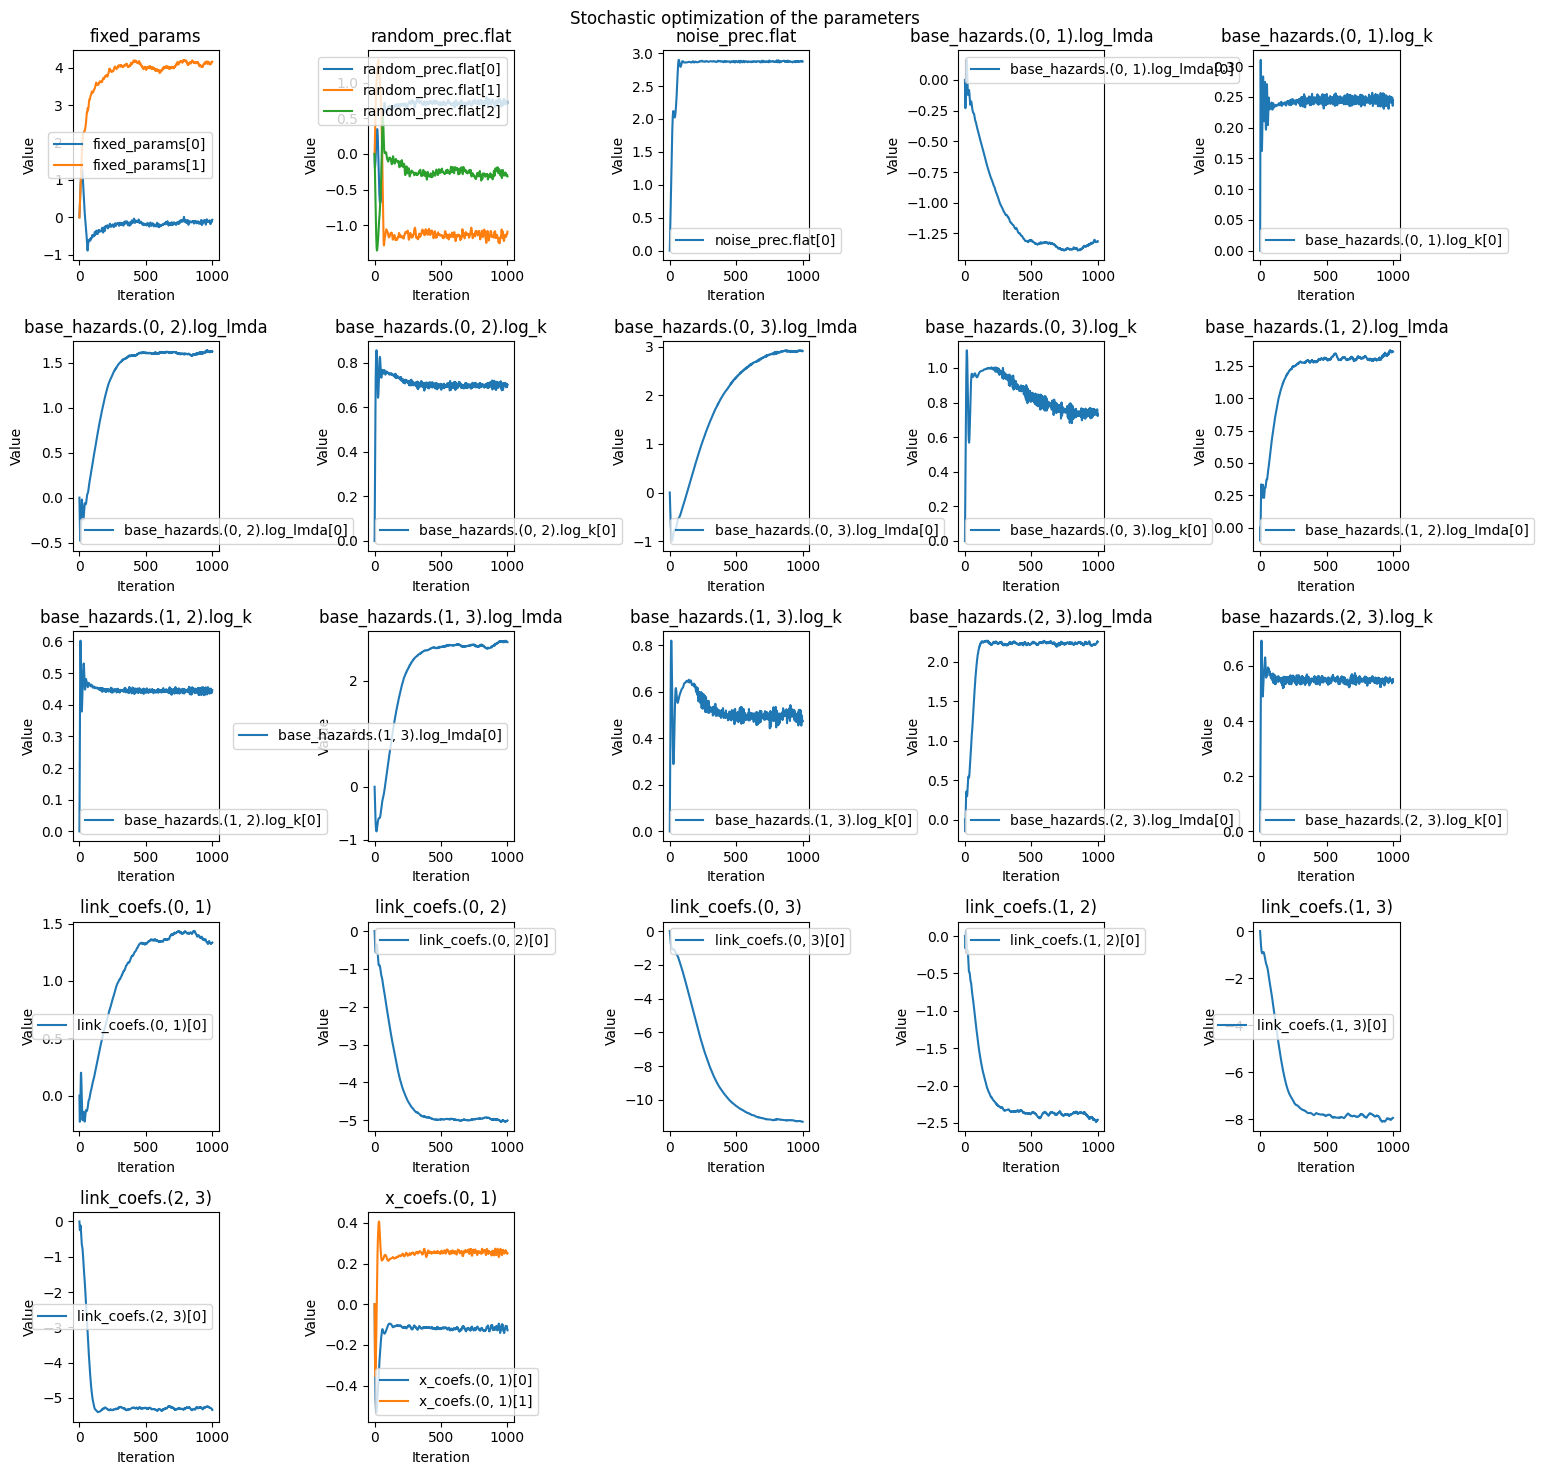

In [45]:
from jmstate.utils import plot_params_history, summary

print(model.params_history_)

summary(model)

plot_params_history(model, figsize=(15, 15))
plt.show()

In [44]:
from torch.distributions import MultivariateNormal

Q = params.random_prec.covariance
gamma = params.fixed_effects
print(Q)

# Create and sample from distribution
dist = MultivariateNormal(torch.zeros(Q.size(0)), Q)

b = dist.sample((50,))
psi = design.indiv_params_fn(gamma, x, b)

# Generates random evaluations points with a minimum distance
t = torch.linspace(0, 4, 50)
y = design.regression_fn(t, psi)

plt.plot(y.detach().squeeze(-1).T)
plt.show()


AttributeError: 'ModelParameters' object has no attribute 'fixed_effects'

In [ ]:
from dataclasses import replace

from jmstate.jobs import PredictTrajectories


def predict_trunc(trunc_time: float):
    trajectories_trunc = [
        [(t, s) for i, (t, s) in enumerate(trajectory) if t <= trunc_time or i == 0]
        for trajectory in data_test.trajectories
    ]
    c = torch.tensor([trajectory[-1][0] for trajectory in data_test.trajectories]).view(
        -1, 1
    )

    trunc_y = data_test.y.clone()
    trunc_y[data_test.t > trunc_time] = torch.nan
    data_test_trunc = replace(
        data_test,
        y=trunc_y,
        trajectories=trajectories_trunc,
        c=torch.maximum(c, trunc_time),
    )

    return model.do(
        data_test_trunc,
        job_factories=[PredictTrajectories(c_max=data_test.c)],
        max_iterations=10,
    ).pred_trajectories


def hier_probs(
    pred_trajectories: list[list[list[tuple[float, Any]]]],
    u: torch.Tensor,
):
    counts = torch.zeros(len(pred_trajectories[0]), 4)
    num_sets = len(pred_trajectories)

    for trajectories in pred_trajectories:
        for i, trajectory in enumerate(trajectories):
            last_valid_state = trajectory[0][1]

            for t, s in reversed(trajectory):
                if t <= u:
                    last_valid_state = s
                    break

            counts[i][last_valid_state] += 1

    return counts / num_sets

ModuleNotFoundError: No module named 'jmstate.jobs'

Running joint model: 100%|██████████| 10/10 [00:04<00:00,  2.47it/s]


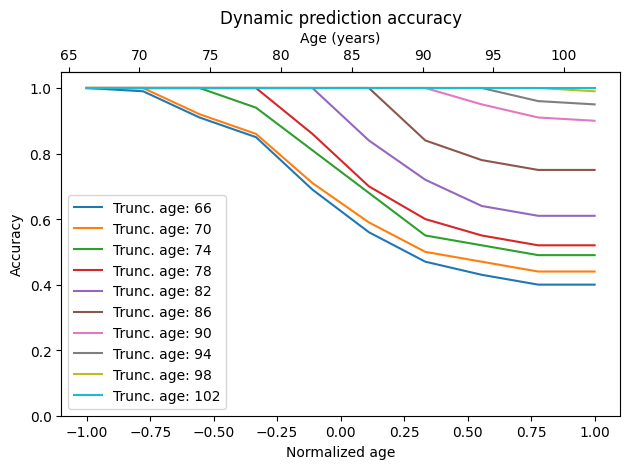

In [ ]:
trunc_times = torch.linspace(-1, 1, 10)
us = torch.linspace(-1, 1, 10)

for trunc_time in trunc_times:
    pred_trajectories = predict_trunc(trunc_time)

    pred_probs = [hier_probs(pred_trajectories, u) for u in us]
    real_states = [hier_probs([data_test.trajectories], u) for u in us]

    accuracy = [
        (real_state.argmax(dim=-1) == pred_prob.argmax(dim=-1)).float().mean()
        for real_state, pred_prob in zip(real_states, pred_probs, strict=True)
    ]

    plt.plot(
        us,
        accuracy,
        label=f"Trunc. age: {int(normalize_t(trunc_time.item(), inverse=True))}",
    )

secax = plt.gca().secondary_xaxis(
    "top", functions=(lambda x: normalize_t(x, inverse=True), normalize_t)
)
secax.set_xlabel("Age (years)")

plt.ylim(0, 1.05)
plt.title("Dynamic prediction accuracy")
plt.xlabel("Normalized age")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/paquid-accuracy.pdf")
plt.show()